In [1]:
from mxlbricks import get_saadat2021, get_matuszynska2016npq
from model_validation import create_report_summary, create_mca_fig, create_pam_fig, inject_fvcb, create_fvcb_fig
import mxlbricks.names as n
from mxlpy import units

In [3]:
from mxlpy import scan
import pandas as pd
import numpy as np

m = get_saadat2021()

m.update_reaction(n.rubisco_carboxylase(), unit=units.mmol / (units.liter * units.second)) # Add Vc unit mM/s

model, co2, vc, Ci, H_cp_co2, gammastar, r_light, A = inject_fvcb(
        model=m,
        co2=n.co2(),
        vc=n.rubisco_carboxylase(),
        pco2=None,
        H_cp_co2=None,
        gammastar=None,
        r_light=None,
        A=None,
    )

# print(model.get_parameter_values()[Ci])
model.update_parameter(n.pfd(), 1000)
variables, fluxes = scan.steady_state(
    model, to_scan=pd.DataFrame({Ci: np.linspace(1, 800, 100)})
)

100%|██████████| 100/100 [00:40<00:00,  2.45it/s]


          PSII   Rubisco  PSI
RuBP  0.103865 -1.095906  NaN
CO2        NaN       NaN  NaN


(<Figure size 640x480 with 2 Axes>, <Axes: >)

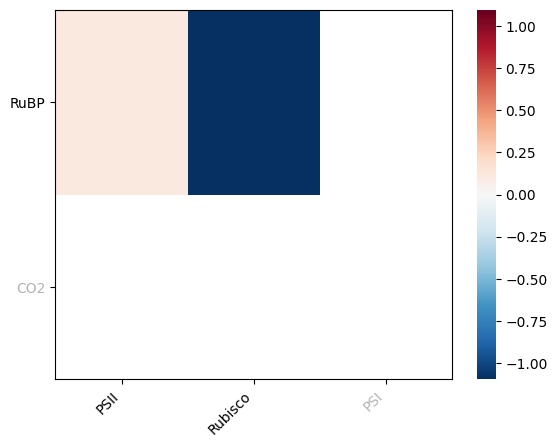

In [2]:
create_mca_fig(
    model=get_saadat2021(),
    co2=n.co2(),
    rubp=n.rubp(),
    coeff_rubisco=n.kcat(n.rubisco_carboxylase()),
    coeff_psi=None,
    coeff_psii="k2"
)

(<Figure size 1500x500 with 2 Axes>, (<Axes: >, <Axes: >))

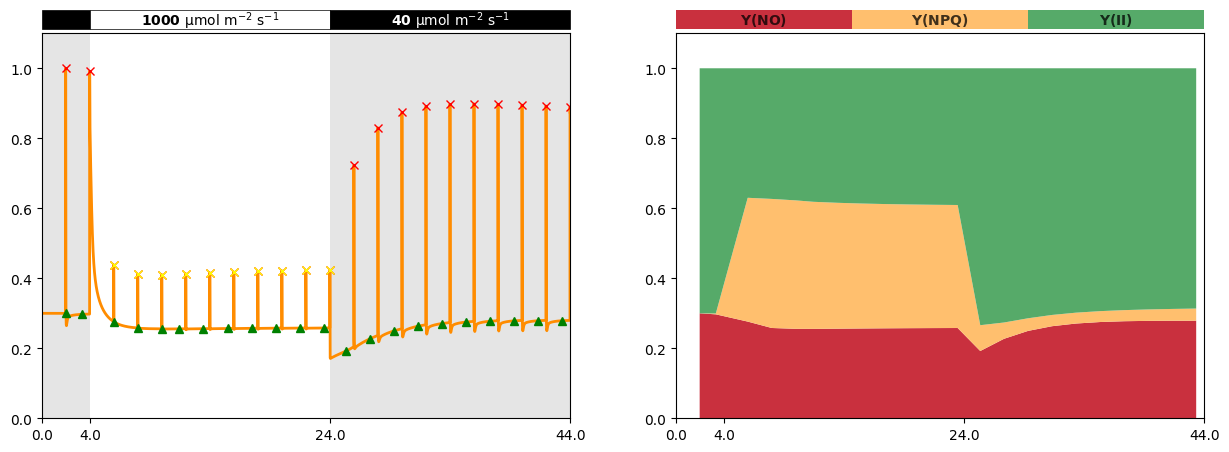

In [3]:
create_pam_fig(
    model=get_saadat2021(),
    pfd=n.pfd(),
    flourescence=n.fluorescence(),
)

  0%|          | 0/100 [00:00<?, ?it/s]


Model(
  _variables={
    '3PGA': Variable(initial_value=0.9167729479368978),
    'BPGA': Variable(initial_value=0.0003814495319659031),
    'GAP': Variable(initial_value=0.00580821050261484),
    'DHAP': Variable(initial_value=0.1277806166216142),
    'FBP': Variable(initial_value=0.005269452472931973),
    'F6P': Variable(initial_value=0.2874944558066638),
    'G6P': Variable(initial_value=0.6612372482712676),
    'G1P': Variable(initial_value=0.03835176039761378),
    'SBP': Variable(initial_value=0.011101373736607443),
    'S7P': Variable(initial_value=0.1494578301900007),
    'E4P': Variable(initial_value=0.00668295494870102),
    'X5P': Variable(initial_value=0.020988553174809618),
    'R5P': Variable(initial_value=0.035155825913785584),
    'RUBP': Variable(initial_value=0.11293260727162346),
    'RU5P': Variable(initial_value=0.014062330254191594),
    'ATP': Variable(initial_value=1.4612747767895344),
    'Ferredoxine (oxidised)': Variable(initial_value=3.715702384326767),
   

100%|██████████| 100/100 [00:41<00:00,  2.39it/s]


after


AttributeError: module 'neonUtilities' has no attribute 'load_by_product'

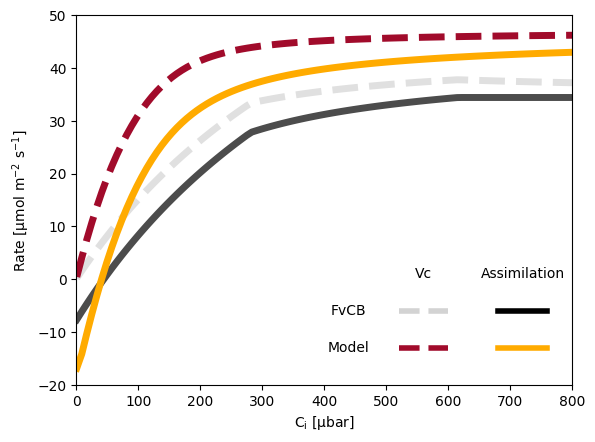

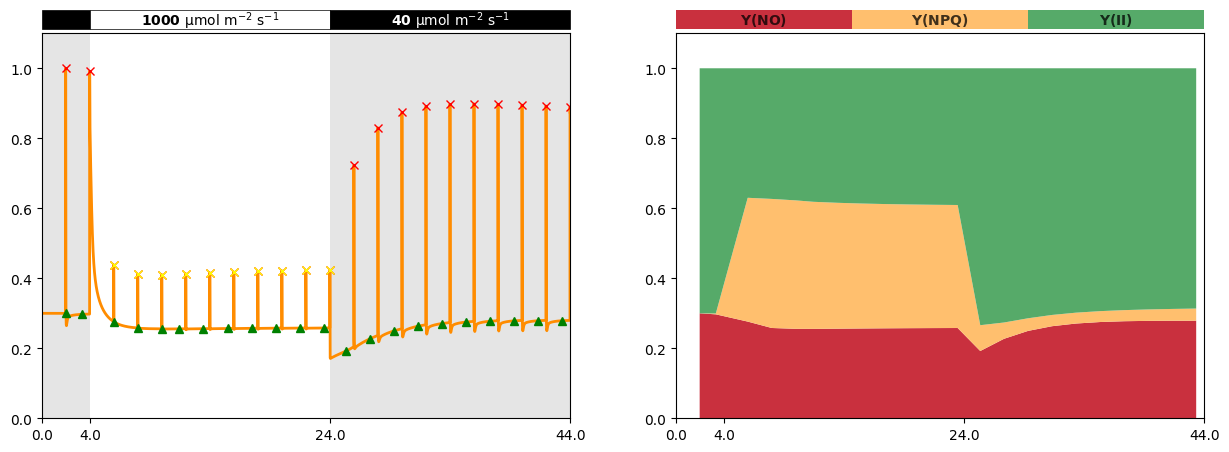

In [4]:
m = get_saadat2021()

m.update_reaction(n.rubisco_carboxylase(), unit=units.mmol / (units.liter * units.second)) # Add Vc unit mM/s

create_report_summary(
    model=m,
    pfd=n.pfd(),
    co2=n.co2(),
    vc=n.rubisco_carboxylase(),
    file_prepend="saadat2021",
    flourescence=n.fluorescence(),
    atp=n.atp(),
    nadph=n.nadph(),
    rubp=n.rubp(),
    coeff_rubisco=n.kcat(n.rubisco_carboxylase())
);

  0%|          | 0/100 [00:00<?, ?it/s]


            Y(NO)    Y(NPQ)     Y(II)  Total
119.52   0.953638  0.000000  0.046362    1.0
239.52   0.945335  0.007946  0.046719    1.0
359.52   0.818412  0.180881  0.000707    1.0
479.52   0.693462  0.305248  0.001290    1.0
599.52   0.623302  0.374967  0.001731    1.0
719.52   0.583898  0.414072  0.002030    1.0
839.52   0.561760  0.436022  0.002218    1.0
959.52   0.549319  0.448350  0.002331    1.0
1079.52  0.542327  0.455277  0.002397    1.0
1199.52  0.538396  0.459170  0.002434    1.0
1319.52  0.536186  0.461358  0.002456    1.0
1439.52  0.534944  0.462588  0.002468    1.0
1559.52  0.554832  0.365166  0.080002    1.0
1679.52  0.652172  0.280841  0.066987    1.0
1799.52  0.727718  0.212422  0.059860    1.0
1919.52  0.785042  0.159419  0.055539    1.0
2039.52  0.827455  0.119747  0.052798    1.0
2159.52  0.858135  0.090848  0.051017    1.0
2279.52  0.879920  0.070237  0.049844    1.0
2399.52  0.895170  0.055767  0.049064    1.0
2519.52  0.905732  0.045725  0.048543    1.0


INFO:root:Downloading 1 NEON DP1.00024.001 files totaling approximately 16.6 MB.


      PSII  PSI  Rubisco
RuBP   NaN  NaN      NaN
CO2    NaN  NaN      NaN


ValueError: Invalid vmin or vmax

Error in callback <function _draw_all_if_interactive at 0x7860b8f9a340> (for post_execute), with arguments args (),kwargs {}:


ValueError: Invalid vmin or vmax

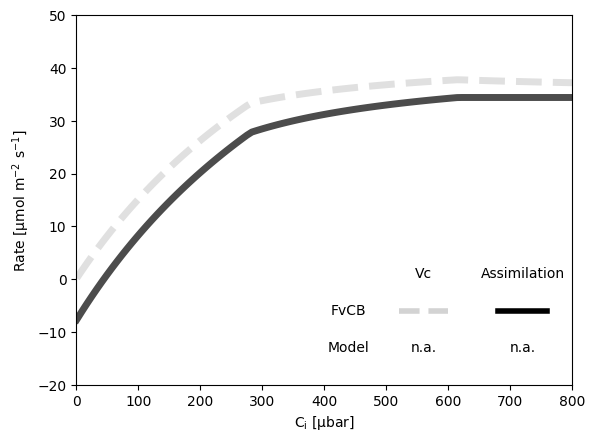

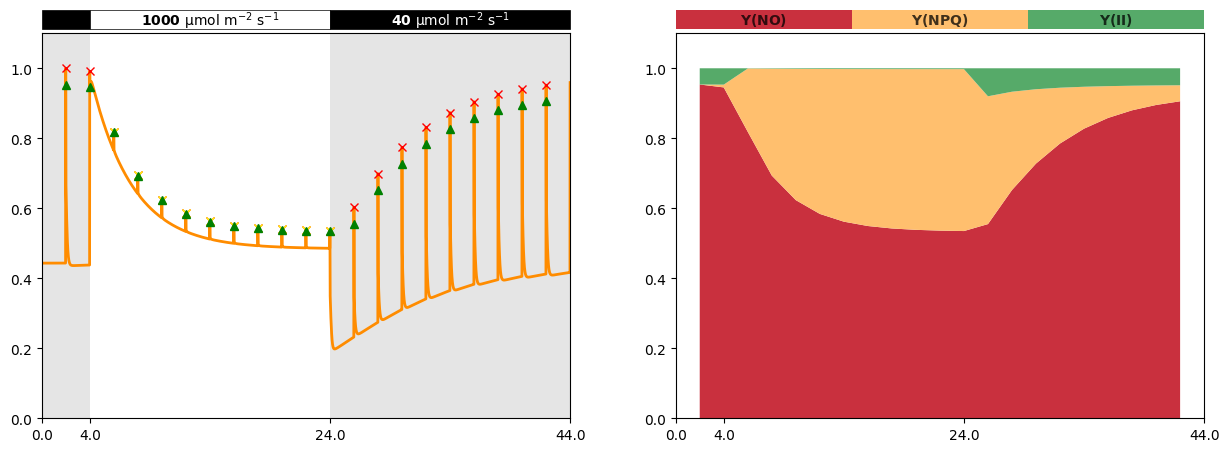

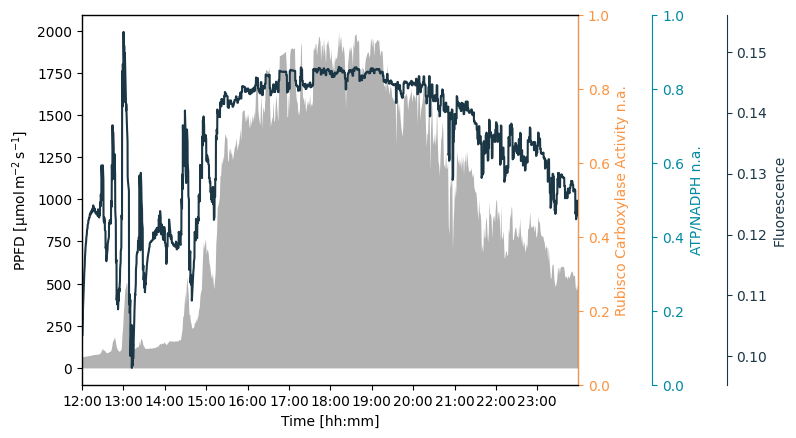

ValueError: Invalid vmin or vmax

<Figure size 640x480 with 2 Axes>

In [5]:
create_report_summary(
    model=get_matuszynska2016npq(),
    pfd=n.pfd(),
    file_prepend="matuszynska2016npq",
    flourescence=n.fluorescence(),
);